<div align="center">

<img src="src/img/logo.png" width="380">

# Predicción de Inventario

**Proyecto de Machine Learning — Trazos y Hojas**

</div>

---

## 1. Introducción

### Problema de negocio

La papelería **Trazos y Hojas** necesita anticipar cuántas unidades de cada producto va a necesitar en inventario, para evitar tanto **roturas de stock** (ventas perdidas) como **sobre-stock** (capital inmovilizado y riesgo de obsolescencia).

Actualmente la reposición se hace de forma intuitiva, basada en la experiencia del personal. El objetivo de este proyecto es comprobar si es posible apoyar esas decisiones de forma objetiva mediante técnicas de Machine Learning.

### Pregunta que responde este proyecto

> **¿Es posible predecir la demanda diaria de los productos de una papelería utilizando Machine Learning y un histórico de ventas de seis meses?**

### Objetivo de modelado

Predecir, para cada **producto** y cada **día**, cuántas unidades se venderán.

- **Tipo de problema:** regresión supervisada sobre datos de panel con estructura temporal.
- **Variable objetivo:** `Unidades_Vendidas` (unidades vendidas por producto y día).
- **Métrica principal:** RMSE, acompañada de MAE y R².

### Dataset

Registro de transacciones del TPV (punto de venta) de la papelería, con el detalle línea a línea de cada venta a lo largo de aproximadamente **seis meses**. Incluye producto, categoría, fecha y hora, cantidad, precio e importes.

### Recorrido del proyecto

```
        Ventas del TPV  (detalle línea a línea)
                 |
                 v
    Agregación diaria por producto  -->  target: Unidades_Vendidas
                 |
                 v
    Selección de productos aptos  (3 reglas de viabilidad)
                 |
                 v
    Feature Engineering  (calendario · lags · estadísticas móviles)
                 |
                 v
    División temporal  (train / test · validación cruzada por fechas)
                 |
                 v
    Comparación de modelos  (RandomForest · CatBoost · LightGBM)
                 |
                 v
    Transformación del target  (log1p)
                 |
                 v
    Optimización de hiperparámetros  (Optuna)
                 |
                 v
    Selección del modelo definitivo
                 |
                 v
    Evaluación final  +  Interpretabilidad (SHAP)
```

---
## 2. Carga de datos

Cargamos el fichero bruto del TPV tal y como se exporta del sistema.

In [1]:
# --- Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# --- Paleta de colores de la marca Trazos y Hojas ---
VERDE_OSCURO = '#4A6035'
MARRON       = '#8F7C52'
VERDE_CLARO  = '#7D955B'
CREMA        = '#EFE6D2'
MOSTAZA      = '#D9A441'
NARANJA      = '#D9824A'

PALETA_MARCA = [VERDE_OSCURO, MARRON, VERDE_CLARO, MOSTAZA, NARANJA, CREMA]
sns.set_palette(sns.color_palette(PALETA_MARCA))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PALETA_MARCA)

In [2]:
# sep=';' -> el archivo usa punto y coma como separador
df_raw = pd.read_csv('src/data_sample/DatosBrutos (1).csv', sep=';', encoding='utf-8')

print(f'Filas: {df_raw.shape[0]}')
print(f'Columnas: {df_raw.shape[1]}')
df_raw.head(3)

Filas: 11613
Columnas: 20


,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Motivo del Descuento,Ventas NETAS,Tipo de Venta,Opción de Comer,Código Fiscal,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,Nominal,A/C Ref,Notas,Identificación del Cliente,ProductId
0,V Hi-tecpoint 0.5 Negro,1.0,Bolígrafos,06/07/2026 10:10:28,0.0,NaN,2.44,Eat in,0.0,NaN,0.51,2.95,1.04,1.40,Tarjeta,NaN,NaN,NaN,NaN,2152893.0
1,V Hi-tecpoint 0.5 Negro,1.0,Bolígrafos,06/07/2026 10:10:28,0.0,NaN,2.44,Eat in,0.0,NaN,0.51,2.95,1.04,1.40,Tarjeta,NaN,NaN,NaN,NaN,2152893.0
2,Copia A4 B/N,1.0,Copisteria,06/07/2026 10:02:41,0.0,NaN,0.12,Eat in,0.0,NaN,0.03,0.15,0.05,0.07,Efectivo,NaN,NaN,NaN,NaN,2160044.0


El dataset contiene el detalle **línea a línea** de cada venta del TPV. Cada fila es un producto dentro de un ticket, no un día de ventas: la agregación a nivel producto-día se realiza al construir la variable objetivo.

Varias columnas (`Código Fiscal`, `Nominal`, `A/C Ref`, `Notas`, `Identificación del Cliente`) presentan un porcentaje de nulos muy elevado y no aportan información predictiva, por lo que se descartan.

---
## 3. Análisis exploratorio

Analizamos la naturaleza de la demanda para entender a qué tipo de problema nos enfrentamos. **Todo el análisis se realiza sobre el conjunto de entrenamiento**, nunca sobre test.

In [3]:
# Construcción del target: unidades vendidas por producto y día
df_raw['Fecha/Hora'] = pd.to_datetime(df_raw['Fecha/Hora'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df_raw = df_raw.dropna(subset=['Fecha/Hora'])
df_raw['Fecha']  = df_raw['Fecha/Hora'].dt.date
df_raw['Semana'] = df_raw['Fecha/Hora'].dt.to_period('W')

ventas_diarias = df_raw.groupby(['Producto', 'Fecha'])['Cantidad'].sum().reset_index()
ventas_diarias.columns = ['Producto', 'Fecha', 'Unidades_Vendidas']

print(f'Periodo: {df_raw["Fecha"].min()} a {df_raw["Fecha"].max()}')
print(f'Productos distintos en el catálogo: {df_raw["Producto"].nunique()}')

Periodo: 2026-01-19 a 2026-07-06
Productos distintos en el catálogo: 1012


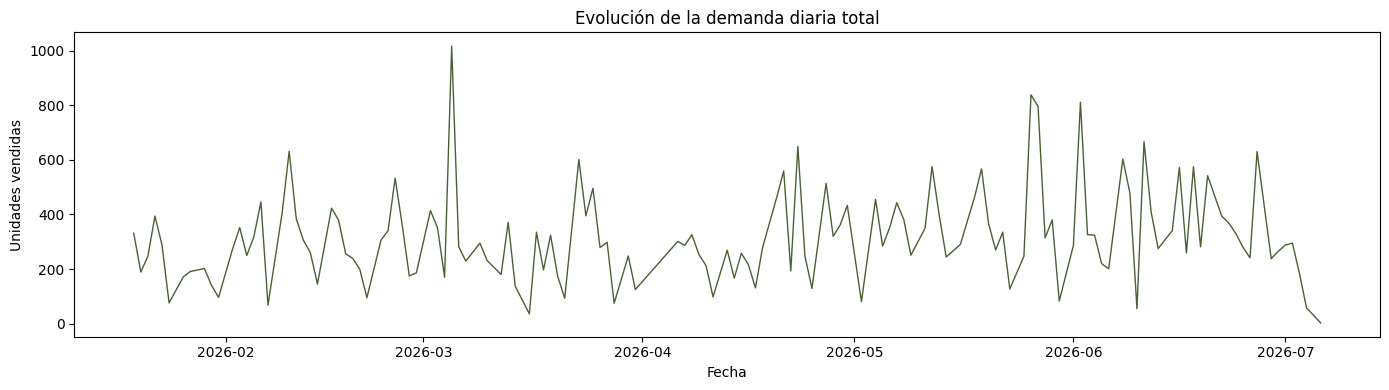

In [4]:
# Evolución de la demanda diaria total
demanda_diaria = ventas_diarias.groupby('Fecha')['Unidades_Vendidas'].sum()

plt.figure(figsize=(14, 4))
plt.plot(demanda_diaria.index, demanda_diaria.values, color=VERDE_OSCURO, linewidth=1)
plt.title('Evolución de la demanda diaria total')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

La serie muestra una **oscilación regular** asociada al día de la semana, con caídas marcadas en los días de menor actividad comercial. Es la primera señal de que el calendario semanal contiene información predictiva.

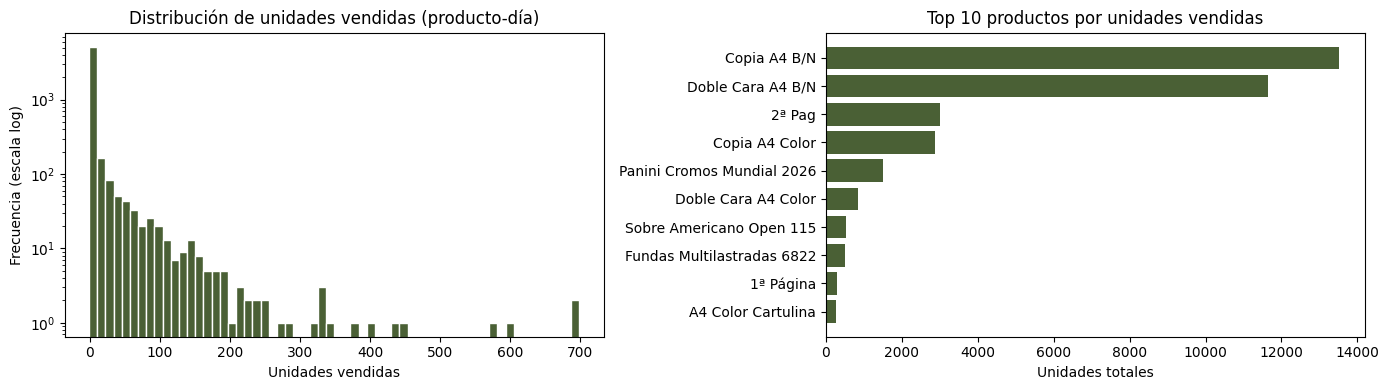

In [5]:
# Distribución del target y concentración de las ventas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ventas_diarias['Unidades_Vendidas'], bins=60, color=VERDE_OSCURO, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Distribución de unidades vendidas (producto-día)')
axes[0].set_xlabel('Unidades vendidas')
axes[0].set_ylabel('Frecuencia (escala log)')

top10 = ventas_diarias.groupby('Producto')['Unidades_Vendidas'].sum().nlargest(10)
axes[1].barh(top10.index, top10.values, color=VERDE_OSCURO)
axes[1].invert_yaxis()
axes[1].set_title('Top 10 productos por unidades vendidas')
axes[1].set_xlabel('Unidades totales')

plt.tight_layout()
plt.show()

### Conclusiones del análisis exploratorio

El EDA revela cuatro características que condicionan por completo el planteamiento del modelo:

1. **Demanda intermitente.** La mayoría de las combinaciones producto-día no registran ninguna venta. El target está fuertemente concentrado en cero, con una distribución muy asimétrica.

2. **Escalas de venta muy dispares.** Los productos de copistería (copias A4 en blanco y negro y color) venden decenas o cientos de unidades diarias, mientras que la mayor parte del catálogo no llega a una unidad al día. Esta diferencia de escala condiciona las métricas de error.

3. **Patrón semanal.** La demanda oscila de forma regular según el día de la semana.

4. **Catálogo muy largo con demanda esporádica.** De los más de mil productos del catálogo, la mayoría se venden de forma demasiado ocasional como para poder modelar su demanda de forma fiable.

Este último punto obliga a filtrar el catálogo antes de modelar.

### Selección de productos aptos para el modelado

No tiene sentido intentar predecir la demanda de un producto que se ha vendido tres veces en seis meses: no hay señal que aprender. Se definen tres reglas de viabilidad, que un producto debe cumplir **simultáneamente**:

| Regla | Criterio | Motivo |
|---|---|---|
| **Volumen** | Al menos 30 transacciones en el periodo | Evita que el modelo memorice en lugar de aprender un patrón |
| **Regularidad** | Venta en al menos 15 de las 25 semanas | Garantiza presencia también en el periodo de test |
| **Estabilidad** | Coeficiente de variación semanal < 1.2 | Descarta productos erráticos que solo aportan ruido |

Estas reglas combinan volumen, regularidad y estabilidad: los tres requisitos que hacen que un producto sea predecible de forma fiable. Es un criterio más exigente que un simple ranking por ingresos.

> **Detalle importante en el cálculo del CV:** el coeficiente de variación se calcula sobre el **panel semanal completo**, rellenando con cero las semanas sin venta. Si se calculara únicamente sobre las semanas con actividad, un producto que vende mucho una semana y nada durante el resto parecería estable, cuando en realidad es de los más erráticos. Incluir los ceros hace que el CV refleje esa irregularidad.

In [6]:
# --- Regla 1: número de transacciones (líneas de venta) por producto ---
transacciones = df_raw.groupby('Producto').size()

# --- Regla 2: número de semanas distintas con venta, por producto ---
semanas_con_venta = df_raw.groupby('Producto')['Semana'].nunique()

# --- Regla 3: coeficiente de variación semanal ---
# Se construye el panel semanal COMPLETO (todas las semanas, con 0 donde no hubo venta).
# Incluir esos ceros es clave: un producto que vende mucho una semana y nada el resto
# es errático, y el coeficiente de variación debe reflejarlo.
todas_semanas    = sorted(df_raw['Semana'].unique())
productos_todos  = df_raw['Producto'].unique()
ventas_semanales = df_raw.groupby(['Producto', 'Semana'])['Cantidad'].sum().reset_index()

indice_semanal = pd.MultiIndex.from_product([productos_todos, todas_semanas],
                                            names=['Producto', 'Semana'])
panel_semanal = (
    ventas_semanales
    .set_index(['Producto', 'Semana'])
    .reindex(indice_semanal, fill_value=0)
    .reset_index()
)

def calcular_cv(x):
    return x.std() / x.mean() if x.mean() > 0 else np.inf

cv_semanal = panel_semanal.groupby('Producto')['Cantidad'].apply(calcular_cv)

# --- Tabla resumen y aplicación de las 3 reglas ---
resumen_seleccion = pd.DataFrame({
    'Transacciones'    : transacciones,
    'Semanas_con_venta': semanas_con_venta,
    'CV_semanal'       : cv_semanal
})

resumen_seleccion['Apto_para_modelar'] = (
    (resumen_seleccion['Transacciones']     >= 30) &
    (resumen_seleccion['Semanas_con_venta'] >= 15) &
    (resumen_seleccion['CV_semanal']         < 1.2)
)

print('Productos que cumplen cada regla por separado:')
print(f'  >= 30 transacciones:      {(resumen_seleccion["Transacciones"] >= 30).sum()}')
print(f'  >= 15 de {len(todas_semanas)} semanas:      {(resumen_seleccion["Semanas_con_venta"] >= 15).sum()}')
print(f'  CV semanal < 1.2:         {(resumen_seleccion["CV_semanal"] < 1.2).sum()}')
print()
print(f'Productos APTOS (cumplen las 3 reglas): {resumen_seleccion["Apto_para_modelar"].sum()} de {len(resumen_seleccion)}')

productos_aptos = resumen_seleccion[resumen_seleccion['Apto_para_modelar']] \
                    .sort_values('Transacciones', ascending=False)
productos_aptos.head()

Productos que cumplen cada regla por separado:
  >= 30 transacciones:      46
  >= 15 de 25 semanas:      49
  CV semanal < 1.2:         43

Productos APTOS (cumplen las 3 reglas): 31 de 1012


,Transacciones,Semanas_con_venta,CV_semanal,Apto_para_modelar
Producto,,,,
Copia A4 B/N,2605,25,0.440053,True
Doble Cara A4 B/N,988,24,0.730152,True
Copia A4 Color,670,24,0.664005,True
1ª Página,284,24,0.509124,True
Servicio menor a 1 hora,265,24,0.879170,True


In [7]:
# Dataset final: producto x día, con ceros en los días sin venta
productos_seleccionados = productos_aptos.index.tolist()

target_final = ventas_diarias[ventas_diarias['Producto'].isin(productos_seleccionados)].copy()

todas_las_fechas = pd.date_range(df_raw['Fecha'].min(), df_raw['Fecha'].max(), freq='D').date
indice_final = pd.MultiIndex.from_product([productos_seleccionados, todas_las_fechas],
                                          names=['Producto', 'Fecha'])

target_final = (
    target_final
    .set_index(['Producto', 'Fecha'])
    .reindex(indice_final, fill_value=0)
    .reset_index()
)

print(f'Dataset final: {len(productos_seleccionados)} productos x {len(todas_las_fechas)} días = {len(target_final)} filas')
print(f'Porcentaje de ceros: {(target_final["Unidades_Vendidas"]==0).mean()*100:.1f}%')
target_final.head(3)

Dataset final: 31 productos x 169 días = 5239 filas
Porcentaje de ceros: 69.2%


,Producto,Fecha,Unidades_Vendidas
0,Copia A4 B/N,2026-01-19,133.0
1,Copia A4 B/N,2026-01-20,94.0
2,Copia A4 B/N,2026-01-21,92.0


De los productos del catálogo, **31 cumplen las tres reglas** y constituyen el universo sobre el que se construye el modelo: 31 productos × 169 días = **5.239 filas**, de las cuales un **69,2 % son ceros**.

Los días sin venta se completan explícitamente con **cero**, ya que "no se vendió nada" es información real y relevante para el modelo, no un dato ausente.

---
## 4. Feature Engineering

Este es el núcleo del proyecto. Los datos brutos del TPV solo contienen qué se vendió y cuándo; toda la capacidad predictiva depende de las variables que seamos capaces de construir a partir de ese histórico.

Se generan tres familias de variables:

### 4.1 Variables de calendario

Capturan la estacionalidad de la demanda: `Dia_semana`, `Fin_de_semana`, `Dia_mes`, `Mes`, `Semana_year`.

### 4.2 Lags (variables de retardo)

Recogen el histórico inmediato de cada producto:

- **`lag_1`** — unidades vendidas el día anterior.
- **`lag_7`** — unidades vendidas hace exactamente 7 días, es decir, el **mismo día de la semana anterior**. Permite comparar días homólogos.

### 4.3 Estadísticas móviles

Resumen el comportamiento reciente, suavizando el ruido diario:

- **`media_movil_7`** y **`media_movil_14`** — nivel medio de ventas de la última semana y de las últimas dos semanas.
- **`std_movil_7`** — volatilidad reciente de la demanda: distingue los productos de venta estable de los erráticos.
- **`tendencia_7_14`** — diferencia entre ambas medias móviles: captura si el producto está acelerando o desacelerando.

Además se incorporan `Categoria` y `Precio` como características del producto.

> **Nota metodológica clave:** todas las variables temporales se calculan con `shift(1)` **antes** de la ventana móvil. Esto garantiza que, al predecir un día concreto, el modelo **solo utiliza información estrictamente anterior** a ese día. Sin esta precaución se produciría *data leakage* y las métricas serían irreales.

In [8]:
target_final['Fecha'] = pd.to_datetime(target_final['Fecha'])
target_final = target_final.sort_values(by=['Producto', 'Fecha']).reset_index(drop=True)

# --- Variables de calendario ---
target_final['Dia_semana']    = target_final['Fecha'].dt.dayofweek
target_final['Fin_de_semana'] = target_final['Dia_semana'].isin([5, 6]).astype(int)
target_final['Dia_mes']       = target_final['Fecha'].dt.day
target_final['Mes']           = target_final['Fecha'].dt.month
target_final['Semana_year']   = target_final['Fecha'].dt.isocalendar().week.astype(int)

# --- Lags y estadísticas móviles (por producto) ---
g = target_final.groupby('Producto')['Unidades_Vendidas']

target_final['lag_1']          = g.shift(1)
target_final['lag_7']          = g.shift(7)
target_final['media_movil_7']  = g.transform(lambda x: x.shift(1).rolling(7).mean())
target_final['media_movil_14'] = g.transform(lambda x: x.shift(1).rolling(14).mean())
target_final['std_movil_7']    = g.transform(lambda x: x.shift(1).rolling(7).std())

# Los NaN corresponden al arranque de cada serie (no hay histórico previo) -> 0
cols_lag = ['lag_1', 'lag_7', 'media_movil_7', 'media_movil_14', 'std_movil_7']
target_final[cols_lag] = target_final[cols_lag].fillna(0)

# --- Características del producto ---
def moda_segura(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

info_producto = (
    df_raw.groupby('Producto')
    .agg(Categoria=('Categoría', moda_segura), Precio=('Precio de Coste', 'mean'))
    .reset_index()
)

target_final = target_final.merge(info_producto, on='Producto', how='left')
target_final['Categoria'] = target_final['Categoria'].fillna('Sin categoría')

# --- Tendencia ---
target_final['tendencia_7_14'] = target_final['media_movil_7'] - target_final['media_movil_14']

print(f'Dataset con features: {target_final.shape[0]} filas x {target_final.shape[1]} columnas')
target_final.head(3)

Dataset con features: 5239 filas x 16 columnas


,Producto,Fecha,Unidades_Vendidas,Dia_semana,Fin_de_semana,Dia_mes,Mes,Semana_year,lag_1,lag_7,media_movil_7,media_movil_14,std_movil_7,Categoria,Precio,tendencia_7_14
0,1ª Página,2026-01-19,1.0,0,0,19,1,4,0.0,0.0,0.0,0.0,0.0,Copisteria,0.050352,0.0
1,1ª Página,2026-01-20,0.0,1,0,20,1,4,1.0,0.0,0.0,0.0,0.0,Copisteria,0.050352,0.0
2,1ª Página,2026-01-21,0.0,2,0,21,1,4,0.0,0.0,0.0,0.0,0.0,Copisteria,0.050352,0.0


---
## 5. División temporal

En un problema con estructura temporal, la división entre entrenamiento y test **no puede ser aleatoria**. Un split aleatorio permitiría al modelo entrenar con datos del futuro para predecir el pasado, lo que produce métricas artificialmente buenas que no se sostienen en producción.

El planteamiento correcto es **cortar por fecha**: se reservan las **últimas tres semanas** como conjunto de test y todo lo anterior se utiliza para entrenar. Así se reproduce exactamente la situación real del negocio: predecir la demanda de los próximos días conociendo únicamente el histórico pasado.

Este conjunto de test **permanece completamente aislado** durante todo el desarrollo y solo se utiliza una única vez, en la evaluación final.

In [9]:
fecha_corte = target_final['Fecha'].max() - pd.Timedelta(weeks=3)

train = target_final[target_final['Fecha'] <  fecha_corte].copy()
test  = target_final[target_final['Fecha'] >= fecha_corte].copy()

print(f'Fecha de corte: {fecha_corte.date()}')
print(f'Train: {train["Fecha"].min().date()} a {train["Fecha"].max().date()} | {train.shape[0]} filas')
print(f'Test:  {test["Fecha"].min().date()} a {test["Fecha"].max().date()} | {test.shape[0]} filas')

Fecha de corte: 2026-06-15
Train: 2026-01-19 a 2026-06-14 | 4557 filas
Test:  2026-06-15 a 2026-07-06 | 682 filas


### Validación cruzada temporal

El mismo principio se aplica **dentro del conjunto de entrenamiento** durante la validación cruzada. Sin embargo, aquí aparece una particularidad de este dataset: al tratarse de un **panel de datos** (31 productos × N fechas), una validación cruzada estándar cortaría por posición de fila y, al estar los datos ordenados por producto, acabaría separando por **producto** en lugar de por **tiempo**.

Para evitarlo se implementa una función de validación cruzada que corta explícitamente **por fechas únicas**, garantizando que todas las filas de un mismo día caen siempre en el mismo lado del split. Cada fold entrena con el pasado y valida con el futuro inmediato, con una ventana de entrenamiento que crece progresivamente.

In [10]:
import sys
sys.path.append('src/utils')
from metrics import rmse
from model_utils import evaluar_modelo, evaluar_modelo_log, encodear_ordinal, split_temporal_por_fecha

train = train.sort_values('Fecha').reset_index(drop=True)

splits_temporales = split_temporal_por_fecha(train, columna_fecha='Fecha', n_splits=5)

for i, (tr_idx, val_idx) in enumerate(splits_temporales):
    f_train = train.loc[tr_idx, 'Fecha']
    f_val   = train.loc[val_idx, 'Fecha']
    print(f'Fold {i+1}: train hasta {f_train.max().date()} ({len(tr_idx)} filas) | '
          f'val {f_val.min().date()}-{f_val.max().date()} ({len(val_idx)} filas)')

Fold 1: train hasta 2026-02-11 (744 filas) | val 2026-02-12-2026-03-07 (744 filas)
Fold 2: train hasta 2026-03-07 (1488 filas) | val 2026-03-08-2026-03-31 (744 filas)
Fold 3: train hasta 2026-03-31 (2232 filas) | val 2026-04-01-2026-04-24 (744 filas)
Fold 4: train hasta 2026-04-24 (2976 filas) | val 2026-04-25-2026-05-18 (744 filas)
Fold 5: train hasta 2026-05-18 (3720 filas) | val 2026-05-19-2026-06-14 (837 filas)


Cada fold respeta estrictamente el orden cronológico: la fecha máxima de entrenamiento es siempre anterior a la mínima de validación, y el conjunto de entrenamiento crece de forma acumulativa. Esta es la validación adecuada para un problema de previsión de demanda.

---
## 6. Selección de variables

Se evaluaron **seis subconjuntos de variables**, obtenidos mediante métodos de selección con lógicas distintas. A lo largo del notebook se identifican como `lista_1` … `lista_6`:

| Conjunto | Método | Lógica |
|---|---|---|
| `lista_1` | Tests estadísticos (Spearman + Kruskal-Wallis) | Relación univariante de cada variable con el target |
| `lista_2` | Información mutua | Dependencia de cualquier tipo, no solo lineal o monótona |
| `lista_3` | `SelectFromModel` | Importancia en un RandomForest, por encima de la media |
| `lista_4` | RFE | Eliminación recursiva de la variable menos importante |
| `lista_5` | SFS | Búsqueda *greedy* que añade variables una a una |
| `lista_6` | Consenso (*hard voting*) | Variables elegidas por al menos 3 de los 5 métodos |

El objetivo no era únicamente reducir la dimensionalidad, sino **identificar las variables que ofrecen el mejor equilibrio entre capacidad predictiva e interpretabilidad**. Cada método mira el problema desde un ángulo diferente y puede llegar a conclusiones distintas, por lo que resulta arriesgado confiar en uno solo.

Aun así, la elección del conjunto definitivo no se basa en el criterio de ningún método concreto: **los seis se comparan a continuación midiendo su rendimiento real** sobre los modelos.

In [17]:
TARGET = 'Unidades_Vendidas'

features_numericas   = ['lag_1', 'lag_7', 'media_movil_7', 'media_movil_14',
                        'std_movil_7', 'tendencia_7_14', 'Precio']
features_categoricas = ['Producto', 'Categoria', 'Dia_semana', 'Mes', 'Fin_de_semana']

# ------------------------------------------------------------
# Conjuntos de variables resultantes de cada método de selección.
# El proceso completo (tests estadísticos, MI, SelectFromModel, RFE, SFS y
# el consenso por hard voting) está documentado en el notebook de trabajo.
# ------------------------------------------------------------

# Tests estadísticos — Spearman (numéricas) + Kruskal-Wallis (categóricas)
lista_1 = ['lag_7', 'media_movil_7', 'media_movil_14', 'std_movil_7', 'lag_1',
           'Precio', 'tendencia_7_14', 'Producto', 'Categoria', 'Dia_semana',
           'Fin_de_semana']

# Información mutua — variables por encima de la puntuación media
lista_2 = ['Producto', 'media_movil_14', 'std_movil_7', 'Precio',
           'media_movil_7', 'Categoria']

# SelectFromModel — importancia en RandomForest por encima de la media
lista_3 = ['media_movil_14', 'lag_7', 'lag_1', 'media_movil_7',
           'std_movil_7', 'Producto']

# RFE — eliminación recursiva hasta 6 variables
lista_4 = ['lag_1', 'lag_7', 'media_movil_7', 'media_movil_14',
           'std_movil_7', 'Dia_semana']

# SFS — búsqueda greedy hacia delante hasta 6 variables
lista_5 = ['Precio', 'Producto', 'Categoria', 'Dia_semana', 'Mes', 'Fin_de_semana']

# Consenso — variables elegidas por al menos 3 de los 5 métodos
lista_6 = ['media_movil_14', 'media_movil_7', 'std_movil_7', 'Producto',
           'lag_7', 'lag_1', 'Dia_semana', 'Categoria', 'Precio']

listas_features = {
    'lista_1': lista_1,
    'lista_2': lista_2,
    'lista_3': lista_3,
    'lista_4': lista_4,
    'lista_5': lista_5,
    'lista_6': lista_6
}

for nombre, feats in listas_features.items():
    print(f'{nombre} ({len(feats)}): {feats}')

lista_1 (11): ['lag_7', 'media_movil_7', 'media_movil_14', 'std_movil_7', 'lag_1', 'Precio', 'tendencia_7_14', 'Producto', 'Categoria', 'Dia_semana', 'Fin_de_semana']
lista_2 (6): ['Producto', 'media_movil_14', 'std_movil_7', 'Precio', 'media_movil_7', 'Categoria']
lista_3 (6): ['media_movil_14', 'lag_7', 'lag_1', 'media_movil_7', 'std_movil_7', 'Producto']
lista_4 (6): ['lag_1', 'lag_7', 'media_movil_7', 'media_movil_14', 'std_movil_7', 'Dia_semana']
lista_5 (6): ['Precio', 'Producto', 'Categoria', 'Dia_semana', 'Mes', 'Fin_de_semana']
lista_6 (9): ['media_movil_14', 'media_movil_7', 'std_movil_7', 'Producto', 'lag_7', 'lag_1', 'Dia_semana', 'Categoria', 'Precio']


### Codificación de variables categóricas

Los tres modelos que se van a comparar están basados en **árboles de decisión**. Esto tiene dos implicaciones prácticas:

- **No requieren escalado.** Los árboles buscan puntos de corte, no calculan distancias ni gradientes sobre la magnitud de las variables.
- **Se codifican las categóricas con `OrdinalEncoder`.** Aunque asigne códigos numéricos, un árbol no interpreta esos números como una magnitud ordenada: simplemente prueba cortes hasta aislar los grupos de categorías relevantes. Es el enfoque estándar para modelos de árbol y evita la explosión de columnas del *one-hot encoding* (`Producto` tiene 31 categorías).

El codificador se ajusta **únicamente con train** y se aplica sobre train y test, evitando así cualquier fuga de información.

In [18]:
# Codificación ordinal de las categóricas — fit en train, transform en train y test
listas_encoded = {}
for nombre_lista, features in listas_features.items():
    tr_enc, te_enc = encodear_ordinal(train, test, features, features_categoricas)
    listas_encoded[nombre_lista] = (tr_enc.reset_index(drop=True), te_enc.reset_index(drop=True))
    print(f'{nombre_lista}: {len(features)} features -> {tr_enc.shape[1]} columnas')

lista_1: 11 features -> 11 columnas
lista_2: 6 features -> 6 columnas
lista_3: 6 features -> 6 columnas
lista_4: 6 features -> 6 columnas
lista_5: 6 features -> 6 columnas
lista_6: 9 features -> 9 columnas


---
## 7. Comparación de modelos

### Métricas de evaluación

Se emplean tres métricas complementarias, ya que ninguna describe por sí sola el comportamiento de un modelo de regresión:

- **RMSE** *(métrica principal)* — penaliza con más fuerza los errores grandes. En previsión de demanda, un error grande (predecir 10 cuando se venden 100) provoca una rotura de stock, mientras que un error de dos unidades tiene un impacto operativo menor. Se expresa en las mismas unidades que el target.
- **MAE** — error absoluto medio, menos sensible a valores atípicos. Refleja el error habitual de predicción.
- **R²** — proporción de la variabilidad de la demanda explicada por el modelo.

Adicionalmente se analiza la **desviación estándar** de cada métrica entre folds: un modelo con buen error medio pero alta desviación es inestable y poco fiable.

### Modelos seleccionados

| Modelo | Rol |
|---|---|
| **DummyRegressor** | Baseline. Predice siempre la media; cualquier modelo debe superarlo |
| **RandomForest** | Ensemble por *bagging*. Robusto frente al ruido |
| **CatBoost** | *Gradient boosting* orientado a datos tabulares con categóricas |
| **LightGBM** | *Gradient boosting* de alto rendimiento, referencia en datos tabulares |

No se incluyen modelos lineales: la relación entre las variables y una demanda intermitente, con muchos ceros y picos pronunciados, dista mucho de ser lineal.

Los tres modelos se evalúan sobre **cada uno de los 6 conjuntos de variables**, con la validación cruzada temporal definida anteriormente.

In [19]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score

TARGET = 'Unidades_Vendidas'

scorers = {
    'RMSE': make_scorer(rmse, greater_is_better=False),
    'MAE' : make_scorer(mean_absolute_error, greater_is_better=False),
    'R2'  : make_scorer(r2_score)
}

# Se limita la profundidad de los árboles para controlar el sobreajuste
modelos = {
    'RandomForest': RandomForestRegressor(random_state=42, max_depth=6, n_estimators=100),
    'CatBoost'    : CatBoostRegressor(random_state=42, verbose=0, depth=6),
    'LightGBM'    : LGBMRegressor(random_state=42, verbosity=-1, max_depth=6, num_leaves=31)
}

In [22]:
cv = splits_temporales
resultados = []

# Baseline
resultados.append(
    evaluar_modelo(DummyRegressor(strategy='mean'),
                   listas_encoded['lista_1'][0], train[TARGET],
                   cv, scorers, 'DummyRegressor', 'baseline')
)

# Comparativa: 3 modelos x 6 listas de features
for nombre_modelo, modelo in modelos.items():
    for nombre_lista in listas_features.keys():
        resultados.append(
            evaluar_modelo(modelo, listas_encoded[nombre_lista][0], train[TARGET],
                           cv, scorers, nombre_modelo, nombre_lista)
        )

df_resultados = pd.DataFrame(resultados).sort_values('RMSE_medio').reset_index(drop=True)
df_resultados.insert(0, 'Ranking', range(1, len(df_resultados) + 1))
df_resultados

,Ranking,Modelo,Features,RMSE_medio,RMSE_std,MAE_medio,MAE_std,R2_medio,R2_std,Tiempo_seg
0,1,LightGBM,lista_5,24.0145,5.5316,5.9335,1.0888,0.3685,0.1383,0.22
1,2,RandomForest,lista_5,24.1629,5.6968,5.1240,0.7503,0.3517,0.1951,0.89
2,3,LightGBM,lista_1,24.6677,5.4947,6.0395,0.7422,0.3234,0.1829,0.13
3,4,LightGBM,lista_4,24.8265,5.6899,5.9780,0.6523,0.3190,0.1794,0.12
4,5,LightGBM,lista_6,24.9030,5.4924,5.9768,0.6431,0.3146,0.1701,0.14
5,6,RandomForest,lista_4,24.9699,5.9818,5.8169,0.7456,0.3141,0.1819,1.10
6,7,RandomForest,lista_6,25.0649,5.6387,5.8300,0.6429,0.3082,0.1693,1.43
7,8,RandomForest,lista_1,25.2240,5.4283,5.9312,0.7308,0.2821,0.2395,1.58
8,9,CatBoost,lista_1,25.7112,5.4818,5.7515,0.4980,0.2783,0.1262,9.81
9,10,LightGBM,lista_3,25.8562,5.4182,6.2945,0.6564,0.2577,0.1851,0.11


### Conclusiones de la comparativa

- **Todos los modelos superan al baseline** (DummyRegressor, RMSE ≈ 30.7 con R² ≈ 0), lo que confirma que aprenden un patrón real.
- **LightGBM y RandomForest dominan** la comparativa, muy parejos entre sí. **CatBoost** queda sistemáticamente por detrás y es además unas 50 veces más lento, lo que lo descarta como candidato.
- El mejor resultado lo obtiene **LightGBM**, con un tiempo de entrenamiento mínimo.
- Las desviaciones estándar entre folds son moderadas, señal de que los modelos son razonablemente estables a lo largo del tiempo.

Antes de optimizar el modelo ganador, se aborda la asimetría del target detectada en el EDA.

### Transformación logarítmica del target

El análisis exploratorio mostró que la variable objetivo presenta una **fuerte asimetría a la derecha**: la mayoría de los registros son ceros o valores muy bajos, mientras que unos pocos productos de copistería alcanzan picos de cientos de unidades diarias.

Se aplica la transformación **`log1p`** al target durante el entrenamiento, revirtiéndola con `expm1` en la predicción para medir siempre las métricas en la escala original (unidades vendidas). Se emplea `log1p` en lugar del logaritmo simple porque **admite el valor cero** (`log1p(0) = 0`), imprescindible dado el alto porcentaje de días sin venta. Las predicciones negativas que puedan surgir al revertir la transformación se recortan a cero, ya que no tienen sentido en unidades vendidas.

In [23]:
resultados_log = []

resultados_log.append(
    evaluar_modelo_log(DummyRegressor(strategy='mean'),
                       listas_encoded['lista_1'][0], train[TARGET],
                       splits_temporales, 'DummyRegressor', 'baseline')
)

for nombre_modelo, modelo in modelos.items():
    for nombre_lista in listas_features.keys():
        resultados_log.append(
            evaluar_modelo_log(modelo, listas_encoded[nombre_lista][0], train[TARGET],
                               splits_temporales, nombre_modelo, nombre_lista)
        )

df_resultados_log = pd.DataFrame(resultados_log).sort_values('RMSE_medio').reset_index(drop=True)
df_resultados_log.insert(0, 'Ranking', range(1, len(df_resultados_log) + 1))
df_resultados_log.head(8)

,Ranking,Modelo,Features,RMSE_medio,RMSE_std,MAE_medio,MAE_std,R2_medio,R2_std,Tiempo_seg
0,1,LightGBM,lista_5,24.4313,6.5983,4.6235,0.7553,0.3707,0.0632,0.22
1,2,RandomForest,lista_6,24.9417,6.6410,4.6872,0.6699,0.3435,0.0579,1.40
2,3,RandomForest,lista_4,24.9529,6.4363,4.7763,0.6384,0.3393,0.0674,1.10
3,4,RandomForest,lista_1,24.9950,6.5713,4.7222,0.6608,0.3392,0.0625,1.64
4,5,RandomForest,lista_5,25.3069,7.4280,4.6524,0.9094,0.3316,0.0753,0.87
5,6,LightGBM,lista_6,25.3097,6.4909,4.9375,0.6900,0.3158,0.0967,0.21
6,7,CatBoost,lista_5,25.3452,5.9141,4.9398,0.6589,0.3115,0.0669,7.26
7,8,LightGBM,lista_4,25.3952,6.2371,5.0410,0.6808,0.3071,0.1042,0.18


**Efecto de la transformación.** El `log1p` no mejora sustancialmente el RMSE ni el R², pero sí aporta 
dos ventajas relevantes:

- **Reduce el MAE** de forma notable (de 5.93 a 4.62 en el mejor modelo, una mejora del 22 %): el modelo 
  acierta mejor en el grueso del catálogo.
- **Duplica la estabilidad del modelo**: la desviación estándar del R² entre folds se reduce a menos de 
  la mitad (de 0.138 a 0.063).

El RMSE no mejora porque sigue dominado por los picos de los productos de alto volumen, que la 
transformación comprime deliberadamente. Se adopta la transformación por su mejor error medio y mayor 
estabilidad, características preferibles en un contexto donde interesa predecir con fiabilidad **todo el 
catálogo** y no solo los productos de mayor rotación.

---
## 8. Optimización de hiperparámetros

Dado que **LightGBM obtuvo el mejor rendimiento en la comparación inicial** —tanto con el target original como con la transformación `log1p`— y lo hizo además con un coste computacional muy inferior al de sus competidores, se decide optimizar sus hiperparámetros para maximizar su capacidad predictiva.

Se compararon dos estrategias de optimización: una búsqueda clásica en dos fases (**RandomSearch** para explorar el espacio de forma amplia, seguida de **GridSearch** para refinar la zona más prometedora) y la **optimización bayesiana con Optuna**, que aprende de cada iteración para dirigir automáticamente la búsqueda sin necesidad de acotar los rangos manualmente.

| Método | RMSE (CV) |
|---|---|
| Sin optimizar (parámetros por defecto) | 24.43 |
| RandomSearch | 24.35 |
| RandomSearch → GridSearch | 24.19 |
| **Optuna** | **24.16** |

**Optuna obtiene el mejor resultado** y es además más eficiente, por lo que se adopta como método definitivo. El detalle de las tres búsquedas está documentado en el notebook de trabajo.

Los hiperparámetros optimizados y sus rangos de búsqueda son:

| Hiperparámetro | Rango explorado |
|---|---|
| `n_estimators` | 100 – 600 |
| `learning_rate` | 0.01 – 0.2 (escala logarítmica) |
| `max_depth` | 3 – 10 |
| `num_leaves` | 15 – 80 |
| `reg_alpha`, `reg_lambda` | 0 – 1 |
| `subsample`, `colsample_bytree` | 0.6 – 1.0 |
| `min_child_samples` | 5 – 40 |

La mejora respecto al modelo por defecto es reducida (~1%), lo que constituye un hallazgo relevante: **el rendimiento está limitado por la naturaleza del problema** —demanda intermitente, muchos ceros y escalas dispares— y no por la configuración de los hiperparámetros.

In [24]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective_lgbm(trial, X, y):
    """Entrena sobre log1p(y) y devuelve el RMSE medio en la escala original,
    usando la validación cruzada temporal por fechas."""
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'num_leaves'       : trial.suggest_int('num_leaves', 15, 80),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 1),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 40),
        'random_state'     : 42,
        'verbosity'        : -1
    }

    rmse_folds = []
    for tr_idx, val_idx in splits_temporales:
        modelo = LGBMRegressor(**params)
        modelo.fit(X.loc[tr_idx], np.log1p(y.loc[tr_idx]))
        y_pred = np.clip(np.expm1(modelo.predict(X.loc[val_idx])), 0, None)
        rmse_folds.append(np.sqrt(mean_squared_error(y.loc[val_idx], y_pred)))

    return np.mean(rmse_folds)

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# Optimización sobre lista_5, el conjunto de features ganador de la comparativa
X_lista5 = listas_encoded['lista_5'][0]

study_lista5 = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lista5.optimize(lambda t: objective_lgbm(t, X_lista5, train[TARGET]), n_trials=100)

print('Mejores hiperparámetros:', study_lista5.best_params)
print(f'Mejor RMSE (CV): {study_lista5.best_value:.4f}')

Mejores hiperparámetros: {'n_estimators': 449, 'learning_rate': 0.08407515650595779, 'max_depth': 8, 'num_leaves': 67, 'reg_alpha': 0.7685218732020109, 'reg_lambda': 0.2060114465730865, 'subsample': 0.6173680711026117, 'colsample_bytree': 0.9297795737136191, 'min_child_samples': 12}
Mejor RMSE (CV): 24.1609


---
## 9. Selección del modelo definitivo

Antes de dar por cerrado el modelo, se analiza **en qué se apoya** para predecir. Este paso resulta ser el más determinante de todo el proyecto.

In [26]:
# Modelo con lista_5 y sus hiperparámetros óptimos
X_train_l5 = listas_encoded['lista_5'][0]
X_test_l5  = listas_encoded['lista_5'][1]

modelo_l5 = LGBMRegressor(**study_lista5.best_params, random_state=42, verbosity=-1)
modelo_l5.fit(X_train_l5, np.log1p(train[TARGET]))
y_pred_l5 = np.clip(np.expm1(modelo_l5.predict(X_test_l5)), 0, None)

print('=== LightGBM lista_5 — evaluación en test ===')
print(f'RMSE: {rmse(test[TARGET], y_pred_l5):.4f}')
print(f'MAE:  {mean_absolute_error(test[TARGET], y_pred_l5):.4f}')
print(f'R2:   {r2_score(test[TARGET], y_pred_l5):.4f}')
print()

imp_l5 = pd.DataFrame({
    'Feature'   : X_train_l5.columns,
    'Importance': modelo_l5.feature_importances_
}).sort_values('Importance', ascending=False)
print(imp_l5.to_string(index=False))

=== LightGBM lista_5 — evaluación en test ===
RMSE: 25.2325
MAE:  4.3924
R2:   0.2966

      Feature  Importance
   Dia_semana        1989
       Precio        1893
          Mes        1806
     Producto        1271
    Categoria         432
Fin_de_semana           1


### Un hallazgo determinante

El conjunto de variables mejor clasificado en la comparativa (**lista_5**, obtenida mediante Sequential Feature Selection) **no incluye ninguna variable de tipo lag ni media móvil**. El modelo se apoya casi exclusivamente en variables de calendario (`Dia_semana`, `Mes`) y de producto (`Precio`, `Producto`, `Categoria`).

Esto es problemático desde el punto de vista del negocio: en un problema de previsión de demanda, el **histórico reciente de ventas** es conceptualmente uno de los mejores predictores. Un modelo que lo ignora resulta difícil de defender, por muy buena que sea su métrica.

La causa es conocida: SFS realiza una búsqueda *greedy* y tiende a descartar los lags cuando están muy correlacionados entre sí, prefiriendo añadir variables más diversas.

### Comparación justa: cada lista con sus propios hiperparámetros

Para decidir con criterio se optimizaron mediante Optuna **las tres listas que sí incorporan variables temporales** (`lista_1`, `lista_4` y `lista_6`), cada una con su propia búsqueda de hiperparámetros —100 trials y la misma validación cruzada temporal—, y se evaluaron sobre el conjunto de test. Solo así la comparación es justa: cada conjunto de variables compite con la configuración ajustada a su medida.

In [27]:
# Optimización independiente de las tres listas que incluyen variables temporales
studies = {}
resultados_finales = []

for nombre in ['lista_1', 'lista_4', 'lista_6']:
    X_tr = listas_encoded[nombre][0]
    X_te = listas_encoded[nombre][1]

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(lambda t, X=X_tr: objective_lgbm(t, X, train[TARGET]), n_trials=100)
    studies[nombre] = study

    # Evaluación en test con sus propios hiperparámetros óptimos
    modelo = LGBMRegressor(**study.best_params, random_state=42, verbosity=-1)
    modelo.fit(X_tr, np.log1p(train[TARGET]))
    y_p = np.clip(np.expm1(modelo.predict(X_te)), 0, None)

    resultados_finales.append({
        'Lista'    : nombre,
        'RMSE_CV'  : round(study.best_value, 4),
        'RMSE_test': round(rmse(test[TARGET], y_p), 4),
        'MAE_test' : round(mean_absolute_error(test[TARGET], y_p), 4),
        'R2_test'  : round(r2_score(test[TARGET], y_p), 4)
    })

df_final = pd.DataFrame(resultados_finales).sort_values('RMSE_test').reset_index(drop=True)
df_final

,Lista,RMSE_CV,RMSE_test,MAE_test,R2_test
0,lista_4,24.7618,23.9942,4.0457,0.3639
1,lista_6,24.6859,24.5707,3.9956,0.3330
2,lista_1,24.5176,24.7652,4.1157,0.3224


### Resultados

| Lista | RMSE (CV) | RMSE (test) | MAE (test) | R² (test) |
|---|---|---|---|---|
| lista_1 | **24.52** | 24.77 | 4.12 | 0.322 |
| lista_6 | 24.69 | 24.57 | **4.00** | 0.333 |
| **lista_4** | 24.76 | **23.99** | 4.05 | **0.364** |

El resultado es revelador: **el orden en validación cruzada se invierte por completo en el conjunto de test**. `lista_1` obtiene el mejor RMSE durante la validación pero es la que peor generaliza, mientras que `lista_4`, la peor en validación, resulta ser **la mejor sobre datos completamente nuevos**, con el RMSE más bajo (23.99) y el mayor poder explicativo (R² 0.364) de todo el proyecto.

Esta inversión confirma que `lista_4` es el conjunto que **mejor generaliza**: las otras dos ajustan algo mejor los datos de validación, pero se degradan al enfrentarse a datos que no han visto nunca.

### Decisión

**Se selecciona `lista_4` como conjunto de variables definitivo.** La elección se apoya en tres razones convergentes:

1. **Es el mejor modelo sobre el conjunto de test**, el único juez imparcial del rendimiento real en producción.
2. **Supera también al modelo basado en `lista_5`** (RMSE 23.99 frente a 25.23), pese a que este último había ganado la comparativa inicial en validación cruzada.
3. **Es coherente con la naturaleza del problema**: fundamenta sus predicciones en el histórico reciente de la demanda, lo que lo hace robusto e interpretable desde el punto de vista del negocio.

---
## 10. Modelo final y evaluación

El modelo definitivo es **LightGBM entrenado sobre `lista_4`**, con transformación `log1p` del target y los hiperparámetros optimizados específicamente para este conjunto de variables mediante Optuna.

Se entrena con la totalidad del conjunto de entrenamiento y se evalúa sobre el conjunto de test —las últimas tres semanas, aisladas desde el inicio del proyecto. Este resultado representa el rendimiento real esperado en producción.

In [28]:
X_train_final = listas_encoded['lista_4'][0]
X_test_final  = listas_encoded['lista_4'][1]

modelo_final = LGBMRegressor(**studies['lista_4'].best_params, random_state=42, verbosity=-1)
modelo_final.fit(X_train_final, np.log1p(train[TARGET]))

y_pred = np.clip(np.expm1(modelo_final.predict(X_test_final)), 0, None)
y_true = test[TARGET]

rmse_test = rmse(y_true, y_pred)
mae_test  = mean_absolute_error(y_true, y_pred)
r2_test   = r2_score(y_true, y_pred)

print('=== EVALUACIÓN FINAL SOBRE TEST ===')
print(f'RMSE: {rmse_test:.4f}')
print(f'MAE:  {mae_test:.4f}')
print(f'R2:   {r2_test:.4f}')

=== EVALUACIÓN FINAL SOBRE TEST ===
RMSE: 23.9942
MAE:  4.0457
R2:   0.3639


### Resultados frente a los demás candidatos

| Modelo | RMSE | MAE | R² |
|---|---|---|---|
| DummyRegressor (baseline) | 30.66 | 10.06 | ≈ 0 |
| LightGBM · `lista_5` (sin lags) | 25.23 | 4.39 | 0.297 |
| **LightGBM · `lista_4` (con lags)** | **23.99** | **4.05** | **0.364** |

El modelo basado en `lista_4` **supera con claridad al de `lista_5`** en las tres métricas, y reduce el error del baseline en más de un 20 %. La revisión crítica del conjunto de variables no solo produjo un modelo más coherente con el problema: produjo también **el modelo más preciso de todo el proyecto**.

Es un resultado que ilustra una idea importante: la métrica de validación no debe ser el único criterio de decisión. Entender en qué se apoya el modelo es igual de necesario.

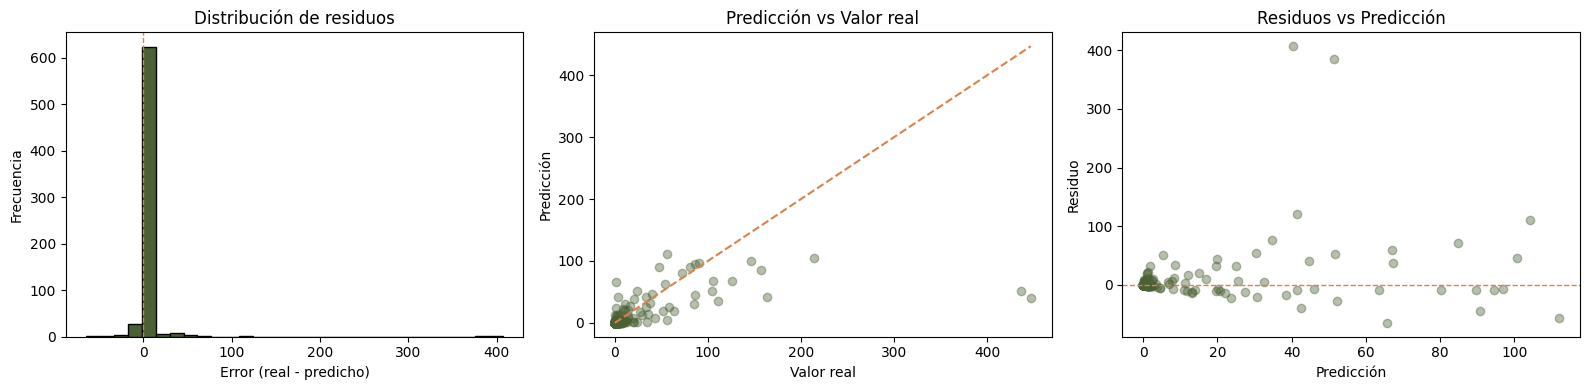

In [29]:
# Análisis de residuos
residuos = y_true.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(residuos, bins=30, edgecolor='black', color=VERDE_OSCURO)
axes[0].axvline(0, color=NARANJA, linestyle='--', linewidth=1)
axes[0].set_title('Distribución de residuos')
axes[0].set_xlabel('Error (real - predicho)')
axes[0].set_ylabel('Frecuencia')

axes[1].scatter(y_true, y_pred, alpha=0.4, color=VERDE_OSCURO)
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
             color=NARANJA, linestyle='--')
axes[1].set_title('Predicción vs Valor real')
axes[1].set_xlabel('Valor real')
axes[1].set_ylabel('Predicción')

axes[2].scatter(y_pred, residuos, alpha=0.4, color=VERDE_OSCURO)
axes[2].axhline(0, color=NARANJA, linestyle='--', linewidth=1)
axes[2].set_title('Residuos vs Predicción')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

**Análisis de residuos.** Los errores se concentran de forma muy marcada en torno a cero: la gran mayoría 
de las predicciones tienen un error mínimo, lo que confirma que el modelo predice con fiabilidad el grueso 
del catálogo.

El gráfico de predicción frente a valor real muestra que los puntos siguen la diagonal en el rango bajo y 
medio de la demanda. Las desviaciones se concentran en los **productos de alta rotación**: destacan dos 
casos con ventas reales próximas a 450 unidades que el modelo estima muy por debajo.

El gráfico de residuos frente a predicción revela que estos errores son **sistemáticamente positivos** en 
los valores altos: el modelo tiende a **subestimar** los picos de demanda. Es un efecto esperable de la 
transformación `log1p`, que comprime deliberadamente los valores extremos para ganar precisión en el resto 
del catálogo.


### Resumen del proyecto

| Elemento | Resultado |
|---|---|
| **Problema** | Predicción de la demanda diaria por producto |
| **Algoritmo** | LightGBM |
| **Variables** | lista_4 — lags, medias móviles, volatilidad y día de la semana |
| **Transformación del target** | `log1p` (revertida con `expm1`) |
| **Optimización** | Optuna · optimización bayesiana · 100 trials |
| **Validación** | Validación cruzada temporal por fechas (5 folds) |
| **Evaluación** | Últimas 3 semanas, aisladas durante todo el desarrollo |
| **RMSE (test)** | **23.99** |
| **MAE (test)** | **4.05** |
| **R² (test)** | **0.364** |
| **Aplicación** | Apoyo a la planificación del inventario |

---
## 11. Interpretabilidad

Un modelo preciso pero opaco tiene poco valor para el negocio. Para entender cómo decide el modelo se emplean dos herramientas que responden a **preguntas distintas y complementarias**:

- **Importancia de variables** → *¿qué variables utiliza más el modelo?* Mide cuánto contribuye cada una a construir los árboles.
- **SHAP** (SHapley Additive exPlanations) → *¿cómo influye cada variable sobre las predicciones?* Además de cuantificar el peso de cada variable, indica **en qué dirección** empuja la predicción: si un valor alto de la variable hace subir o bajar la demanda estimada.

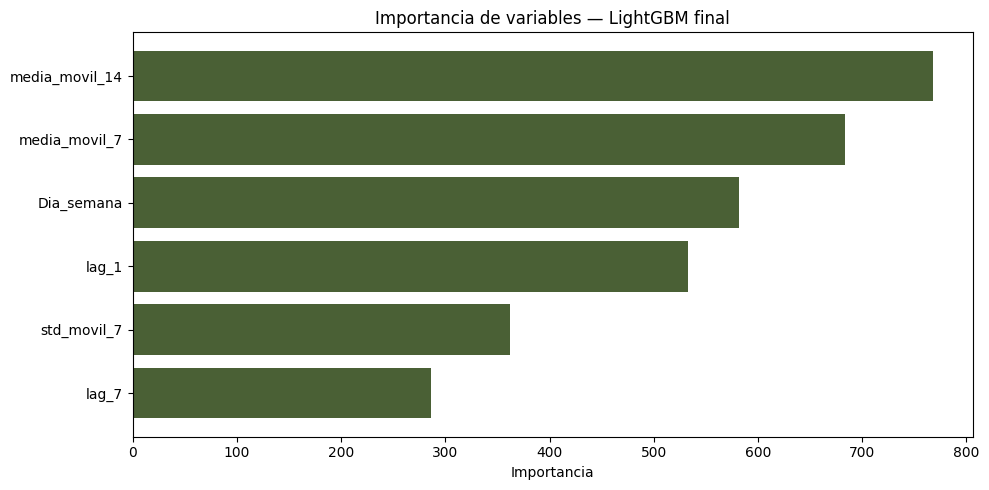

,Feature,Importance
3,media_movil_14,768
2,media_movil_7,684
5,Dia_semana,582
0,lag_1,533
4,std_movil_7,362
1,lag_7,286


In [30]:
importances = pd.DataFrame({
    'Feature'   : X_train_final.columns,
    'Importance': modelo_final.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importances['Feature'], importances['Importance'], color=VERDE_OSCURO)
plt.gca().invert_yaxis()
plt.title('Importancia de variables — LightGBM final')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

importances

El modelo utiliza sobre todo las **variables temporales** —medias móviles, lags y volatilidad reciente— junto con `Dia_semana`. Las variables construidas en el Feature Engineering son, efectivamente, las que sostienen la predicción.

Los valores SHAP permiten ir un paso más allá y ver **el sentido** de cada efecto.

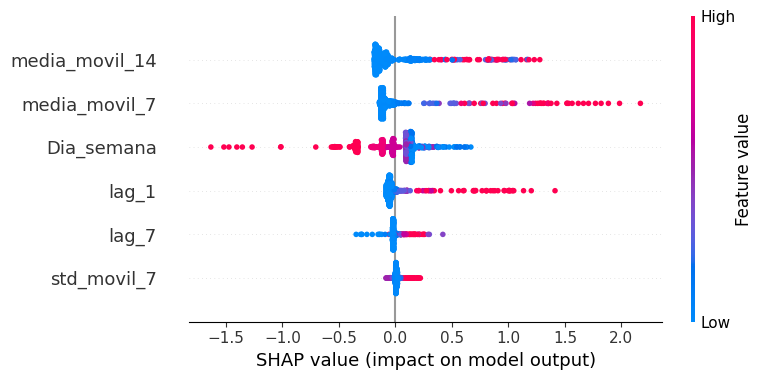

In [31]:
import shap

explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X_test_final)

shap.summary_plot(shap_values, X_test_final, show=True)

### Cómo influye cada variable

El *summary plot* muestra, para cada variable, cómo su valor (rojo = alto, azul = bajo) desplaza la 
predicción hacia arriba o hacia abajo. Dado que el modelo se entrena sobre el target transformado con 
`log1p`, los valores SHAP se expresan en esa escala logarítmica, lo que resulta válido para analizar la 
importancia relativa y el sentido del efecto de cada variable:

- **Medias móviles y `lag_1`:** los valores altos (rojos) se sitúan a la derecha, empujando la predicción 
  al alza. Un producto con demanda reciente elevada seguirá teniéndola; uno cuya demanda ha caído tenderá 
  a mantener esa tendencia. Es la relación esperada y la más influyente del modelo.

- **`std_movil_7`:** el modelo pondera también la **estabilidad** de la demanda reciente, no solo su 
  nivel. Los productos erráticos se tratan de forma distinta a los regulares, lo que evita sobre-reaccionar 
  ante picos puntuales.

- **`Dia_semana`:** presenta un efecto claramente **bidireccional** —unos días empujan la predicción al 
  alza y otros a la baja—, lo que confirma el patrón semanal observado en el análisis exploratorio.

Todas las relaciones aprendidas son **lógicas y explicables**: el modelo no se apoya en correlaciones 
ficticias, lo que aporta confianza sobre su comportamiento en un entorno real.

---
## 12. Persistencia del modelo

Una vez validado, el modelo se guarda mediante `joblib` para poder reutilizarlo sin necesidad de reentrenarlo. **Este sería el artefacto que se integraría en un sistema de predicción diaria** de la papelería.

Se guarda también la **lista de variables** que el modelo espera, ya que sin ella no es posible construir correctamente la entrada en el momento de la inferencia. Finalmente se verifica que el modelo cargado desde disco reproduce exactamente el mismo resultado que el modelo evaluado.

In [32]:
import joblib
import os

os.makedirs('src/models', exist_ok=True)

joblib.dump(modelo_final, 'src/models/modelo_final_lgbm.joblib')
joblib.dump(listas_features['lista_4'], 'src/models/features_modelo_final.joblib')

# Verificación: el modelo cargado debe reproducir exactamente el mismo resultado
modelo_cargado = joblib.load('src/models/modelo_final_lgbm.joblib')
y_pred_verif = np.clip(np.expm1(modelo_cargado.predict(X_test_final)), 0, None)

print('Modelo y features guardados en src/models/')
print(f'RMSE de verificación: {rmse(y_true, y_pred_verif):.4f}')

Modelo y features guardados en src/models/
RMSE de verificación: 23.9942


---
## 13. Conclusiones

### Respuesta a la pregunta del proyecto

> **¿Es posible predecir la demanda diaria de los productos de una papelería utilizando Machine Learning y un histórico de ventas de seis meses?**

**Sí, con matices.** El modelo final predice la demanda diaria con un **error absoluto medio cercano a 4 unidades por predicción** y explica alrededor de un **36 % de la variabilidad** de la demanda sobre datos completamente nuevos.

### El modelo generaliza correctamente

El RMSE sobre test (23.99) es incluso ligeramente mejor que el obtenido en validación cruzada (24.76), lo que indica **ausencia de sobreajuste** y confirma la solidez de la metodología: división temporal, validación cruzada respetando el orden cronológico y evaluación única sobre datos aislados.

Un **R² de 0.36 es un resultado sólido para este problema**: en escenarios de demanda intermitente es habitual obtener valores moderados incluso con modelos de buen rendimiento predictivo, ya que una parte importante de la variabilidad es intrínsecamente impredecible.

### Qué aporta al negocio

El modelo revela que la demanda de la papelería es fundamentalmente **inercial y semanal**. Esto se traduce en dos decisiones concretas:

- **Reposición basada en el histórico reciente** de cada producto, con un error medio de unas cuatro unidades: suficiente para reducir tanto las roturas de stock como el inventario inmovilizado, que era el problema de partida.
- **Planificación semanal** de la reposición y del personal, ajustada a los días de mayor actividad.

### La decisión metodológica más relevante

La comparativa de modelos señalaba como ganador un conjunto de variables que **no incluía el histórico de ventas**. El análisis de interpretabilidad permitió detectarlo, y al optimizar de forma independiente las tres listas que sí incorporan variables temporales se obtuvo un resultado revelador: **el orden en validación cruzada se invertía por completo en el conjunto de test**. El conjunto que peor puntuaba en validación (`lista_4`) resultó ser el que mejor generalizaba, y dio lugar al modelo más preciso de todo el proyecto.

Es la lección central del trabajo: **la métrica de validación no debe ser el único criterio de decisión**. Entender en qué se apoya un modelo, y comprobar su comportamiento sobre datos verdaderamente no vistos, resulta igual de necesario.

### Limitaciones

- **Histórico corto.** Seis meses no permiten capturar la estacionalidad anual (vuelta al cole, Navidad), probablemente muy relevante en este negocio.
- **Catálogo reducido.** Solo 31 de los más de mil productos cumplen los criterios de viabilidad; el resto se vende de forma demasiado esporádica para modelarse con fiabilidad.
- **Error concentrado en los productos de alta rotación**, que son los que peor predice el modelo en términos absolutos.

---
## 14. Trabajo futuro

- **Ampliar el histórico** a uno o dos años para capturar la estacionalidad anual (vuelta al cole, Navidad), previsiblemente la mayor fuente de mejora.
- **Incorporar variables externas**: festivos y calendario escolar, promociones, campañas puntuales (colecciones de cromos).
- **Modelar por separado los productos de alta rotación**, cuyo régimen de demanda es muy distinto al del resto del catálogo y concentra la mayor parte del error.
- **Reentrenar con el histórico completo (train + test)** de cara a un despliegue en producción. Las métricas reportadas en este trabajo corresponden exclusivamente a la evaluación sobre el conjunto de test, que permaneció aislado durante todo el desarrollo.

---

En definitiva, el proyecto demuestra que **es posible construir un sistema de previsión de demanda útil a partir del histórico de ventas disponible**. Aunque el modelo puede seguir mejorándose con un mayor volumen de datos y nuevas variables explicativas, los resultados obtenidos muestran que el uso de técnicas de Machine Learning permite apoyar de forma objetiva las decisiones de reposición y reducir la incertidumbre en la planificación diaria de la papelería.